# **Trabajo práctico - Aprendizaje Automático I**

### Grupo: Traviata.
### Integrantes: Iván Agustín Bravo, María Delfina Kiss, Eric Lützow Holm, Juan Cruz Mendoza y Marcos Andrés Rostan.


# Importacion de bibliotecas y dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, ParameterGrid, RandomizedSearchCV, cross_val_score, cross_val_predict
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, average_precision_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.inspection import permutation_importance
from sklearn.feature_selection import VarianceThreshold
from sklearn.dummy import DummyClassifier

In [ ]:
# cargamos el dataset desde el repositorio de la materia. Con el fin de estandarizar la fuente y no tener que subir el dataset al
# repositorio de GitHub. Tarda un poco más en cargarlo.
url = "https://github.com/aprendizaje-automatico-dc-uba-ar/material/blob/main/tp/01_aprendizaje_supervisado/datos/data.csv?raw=true"
df = pd.read_csv(url)

print('Cantidad de target 0: ', len(df[df['target']==0]), '\nProporción: ', len(df[df['target']==0])/500)
print('Cantidad de target 1: ', len(df[df['target']==1]), '\nProporción: ', len(df[df['target']==1])/500)

Cantidad de target 0:  359 
Proporción:  0.718
Cantidad de target 1:  141 
Proporción:  0.282


---

# 1. Separación de datos



#### Se cuenta con una cantidad limitada de datos, por lo que es importante tomar una buena decisión al comenzar a utilizarlos.

#### 1.1. Evaluar y definir una manera de separar los datos para desarrollo y evaluación.

#### 1.2. ¿Qué consideraciones tuvieron en cuenta para realizar esta división? Justificar.

Queremos partir el dataset de manera de tener una partición de held-out (conjunto de control o de evaluación) para evaluar nuestra configuración. Para eso, podemos tomar el estándar de usar el 15% del total. Luego, es muy importante que esa partición sea representativa del dataset: que la proporción de etiquetas sea aleatoria y balanceada. Es decir, que la proporción de True y False sea la misma que en el resto del dataset. Además, ese 15% no debe tener una propiedad que el resto del dataset no tenga y viceversa. Por ejemplo, que los valores de ciertos atributos sean muy diferentes al del resto.

Sabemos que del total, el 71,8% de las instancias corresponden a 0 (False) y 28,2% a 1 (True). La propuesta final entonces es mezclar primero las instancias y luego tomar esas proporciones para particionar el held-out. Una forma de hacer eso es utilizar los métodos group_by (agrupar por target) y luego sample (tomar una muestra al azar) de dataframe de Pandas. Queremos $0,15 \cdot 359$ de etiqueta 0 y $0,15 \cdot 141$ de etiqueta 1, o sea, 54 y 21 respectivamente.

In [3]:
# vemos el dataframe
df

,rTjs,Sgqo,egGJ,DwEY,Qnno,NebZ,rVTD,eRIp,BbAh,OYJu,...,YfJW,LXKN,GcAh,qTSh,TgIh,kpDd,QDQf,TPVx,FbdX,target
0,-3.057884,6.492121,3.910129,1.397403,0.018045,3.088089,0.182157,-0.318743,-0.615690,-2.407960,...,0.913144,-1.685603,1.193255,-0.134379,-0.241125,0.864049,-1.740255,-1.134003,0.262980,0
1,-0.072814,15.775499,-0.421900,0.768645,0.464642,-0.341264,-0.252583,1.368443,1.199160,-6.794615,...,0.735794,0.161943,-0.072226,0.320684,0.891427,1.639073,-1.381561,0.000326,-0.886779,0
2,-2.907303,32.289386,-0.172693,0.359285,1.105822,1.419213,0.933065,0.540651,0.995223,-7.939494,...,1.068409,-0.123667,0.153210,1.227512,7.204299,0.262021,0.232323,-1.033203,-0.753344,0
3,4.394497,-23.153355,-2.460442,0.514116,-1.802006,-0.843553,1.118796,1.253657,-0.453684,-1.409674,...,-0.225670,0.266595,-1.112167,-0.225133,-3.592521,1.706198,0.720637,0.049659,-0.212137,1
4,-5.270795,2.058165,0.235030,-1.940846,-0.321674,1.419594,-1.944603,1.260702,0.136818,-1.485291,...,-0.339088,1.452778,-0.593938,0.462660,0.772794,0.809459,0.430752,1.446356,-2.127134,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,-22.911250,-19.993854,-1.741496,0.318322,1.548092,-1.278147,0.619454,-1.703399,0.465365,1.975396,...,0.698309,-0.541011,0.847749,-0.073158,0.341735,0.230878,0.123901,0.678477,-1.472541,0
496,-8.868246,11.594718,-5.938479,-0.365995,-0.330750,-1.942732,-0.148195,-0.597193,-1.018020,-1.633626,...,-0.008660,0.427660,-0.538353,-0.416578,3.450356,-1.368120,-1.863118,0.033590,-0.797224,0
497,21.356848,21.833391,-4.338930,0.207909,-1.488410,-0.305953,-2.596184,0.397999,1.079850,8.969353,...,-0.869809,-1.125930,-0.635399,-1.184720,3.240518,-1.463667,-1.194254,-0.987738,-0.973470,1
498,-4.154728,-16.818791,3.652353,-1.200745,-1.049438,-0.645861,-0.686595,0.101903,-0.550578,1.640054,...,1.471306,0.649209,0.639080,0.854587,1.449929,0.899216,1.095544,-1.940683,0.516326,0


In [4]:
# usamos una semilla para que sea reproducible
random_state = 2026

# separamos las instancias por target
verdaderos = df.groupby('target').get_group(1)
falsos = df.groupby('target').get_group(0)

# tomamos una muestra aleatoria del 0,15 de cada clase
held_out_true = verdaderos.sample(frac=0.15, random_state=random_state)
held_out_false = falsos.sample(frac=0.15, random_state=random_state)

# concatenamos las partes del held-out y separamos el conjunto de desarrollo
held_out = pd.concat([held_out_false, held_out_true])
desarrollo = df.drop(held_out.index)

# separamos el subjconjunto de desarrollo de su target
X_dev = desarrollo.drop('target', axis=1)
y_dev = desarrollo['target']

# separamos también el held-out en X e y
X_held_out = held_out.drop('target', axis=1)
y_held_out = held_out['target']

In [5]:
# cantidad de instancias en cada partición
X_dev.shape, y_dev.shape, X_held_out.shape, y_held_out.shape

((425, 200), (425,), (75, 200), (75,))

Antes de avanzar verificamos que la proporción de etiquetas se conserve en las particiones.

In [6]:
print(f"Proporcion de positivos en el conjunto total: {df['target'].mean():.4f}")
print(f"Proporcion de positivos en el conjunto de desarrollo: {y_dev.mean():.4f}")
print(f"Proporcion de positivos en el held-out: {y_held_out.mean():.4f}")

Proporcion de positivos en el conjunto total: 0.2820
Proporcion de positivos en el conjunto de desarrollo: 0.2824
Proporcion de positivos en el held-out: 0.2800


La proporción de positivos se conserva en las 3 particiones. Como además la muestra se tomó al azar dentro de cada clase, ningún criterio pudo favorecer sistemáticamente a ciertas instancias sobre otras.

---

# 2. Construcción de modelos


#### Buscamos construir y evaluar modelos de árboles de decisión, obteniendo una estimación realista de su performance.

#### 2.1. Entrenar un árbol de decisión con altura máxima 3 y el resto de los hiperparámetros en sus valores por defecto.

Vamos a separar el desarrollo nuevamente de manera proporcional a sus etiquetas. Para eso, usamos `train_test_split` de sklearn estratificado. Nos quedamos con un 0,8 de entrenamiento y 0,2 de validación.

In [7]:
# separamos nuestro conjunto de desarrollo en entrenamiento y validación
X_train, X_val, y_train, y_val = train_test_split(
    X_dev,
    y_dev,
    test_size=0.2,
    stratify=y_dev,
    random_state=random_state)

In [8]:
arbol = DecisionTreeClassifier(max_depth=3, criterion="gini")
arbol.fit(X_train, y_train)
y_pred = arbol.predict(X_val)

print(f"Accuracy sobre el subconjunto de validación: {arbol.score(X_val, y_val)}")

Accuracy sobre el subconjunto de validación: 0.6470588235294118


Sobre el 20% de validación obtuvimos un accuracy de 0.6471. Ese número sale de una única partición de 85 instancias, así que depende bastante de cuáles hayan caído del lado de validación. Por eso en el punto siguiente repetimos la estimación con validación cruzada, que promedia sobre varias particiones y da un valor más estable.

#### 2.2. Estimar la performance del modelo utilizando validación cruzada K-fold con K = 5 y las métricas Accuracy, Area Under the Precision-Recall Curve (AUPRC) y Area Under the Receiver Operating Characteristic Curve (AUCROC). Además de calcular las métricas de cada fold y su promedio, calcular el score global –como se vio en clase– utilizando únicamente los folds de validación.

Vamos a utilizar X_dev e y_dev con un Kfold estratificado, de manera que conserve la proporción de etiquetas.

In [9]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state)

# en estos arreglos guardamos las métricas de cada fold
acc_train_folds, acc_val_folds = np.zeros(5), np.zeros(5)
aucroc_train_folds, aucroc_val_folds = np.zeros(5), np.zeros(5)
auprc_train_folds, auprc_val_folds = np.zeros(5), np.zeros(5)

# generamos arreglos para guardar los resultados
y_val_global = np.zeros(len(y_dev))
y_pred_global = np.zeros(len(y_dev))
y_proba_global = np.zeros(len(y_dev))

# convertimos los datos de DataFrame a np.array
X_dev_np = X_dev.to_numpy()
y_dev_np = y_dev.to_numpy()

for fold, (train_idx, val_idx) in enumerate(skf.split(X_dev_np, y_dev_np)):
    # separamos el fold en entrenamiento y validación
    X_tr, X_va = X_dev_np[train_idx], X_dev_np[val_idx]
    y_tr, y_va = y_dev_np[train_idx], y_dev_np[val_idx]

    # entrenamos
    arbol = DecisionTreeClassifier(max_depth=3, criterion="gini", random_state=random_state)
    arbol.fit(X_tr, y_tr)

    # predicciones en entrenamiento
    y_pred_tr = arbol.predict(X_tr)
    y_proba_tr = arbol.predict_proba(X_tr)[:, 1] # probabilidad de True

    # predicciones en validación
    y_pred_va = arbol.predict(X_va)
    y_proba_va = arbol.predict_proba(X_va)[:, 1]

    # métricas entrenamiento
    acc_train_folds[fold] = accuracy_score(y_tr, y_pred_tr)
    aucroc_train_folds[fold] = roc_auc_score(y_tr, y_proba_tr)
    auprc_train_folds[fold] = average_precision_score(y_tr, y_proba_tr)

    # métricas validación
    acc_val_folds[fold] = accuracy_score(y_va, y_pred_va)
    aucroc_val_folds[fold] = roc_auc_score(y_va, y_proba_va)
    auprc_val_folds[fold] = average_precision_score(y_va, y_proba_va)

    # guardamos
    y_val_global[val_idx] = y_va
    y_pred_global[val_idx] = y_pred_va
    y_proba_global[val_idx] = y_proba_va

In [10]:
global_acc = accuracy_score(y_val_global, y_pred_global)
global_aucroc = roc_auc_score(y_val_global, y_proba_global)
global_auprc = average_precision_score(y_val_global, y_proba_global)

In [11]:
header = f"{'Permutación':<14} | {'Acc (train)':>11} | {'Acc (val)':>11} | {'AUPRC (train)':>13} | {'AUPRC (val)':>13} | {'AUCROC (train)':>14} | {'AUCROC (val)':>12}"
separator = "-" * len(header)

print(separator)
print(header)
print(separator)

for i, (acc_tr, acc_v, auprc_tr, auprc_v, aucroc_tr, aucroc_v) in enumerate(
    zip(acc_train_folds, acc_val_folds,
        auprc_train_folds, auprc_val_folds,
        aucroc_train_folds, aucroc_val_folds), start=1
):
    print(f"{i:<14} | {acc_tr:>11.4f} | {acc_v:>11.4f} | {auprc_tr:>13.4f} | {auprc_v:>13.4f} | {aucroc_tr:>14.4f} | {aucroc_v:>12.4f}")

print(separator)

print(f"{'Promedios':<14} | {np.mean(acc_train_folds):>11.4f} | {np.mean(acc_val_folds):>11.4f} | {np.mean(auprc_train_folds):>13.4f} | {np.mean(auprc_val_folds):>13.4f} | {np.mean(aucroc_train_folds):>14.4f} | {np.mean(aucroc_val_folds):>12.4f}")

print(separator)

print(f"{'Global':<14} | {'(NO)':>11} | {global_acc:>11.4f} | {'(NO)':>13} | {global_auprc:>13.4f} | {'(NO)':>14} | {global_aucroc:>12.4f}")

print(separator)

----------------------------------------------------------------------------------------------------------
Permutación    | Acc (train) |   Acc (val) | AUPRC (train) |   AUPRC (val) | AUCROC (train) | AUCROC (val)
----------------------------------------------------------------------------------------------------------
1              |      0.8265 |      0.6000 |        0.7153 |        0.3265 |         0.8626 |       0.5697
2              |      0.8265 |      0.7412 |        0.6862 |        0.4213 |         0.8037 |       0.6411
3              |      0.8353 |      0.6235 |        0.6981 |        0.2895 |         0.8506 |       0.4754
4              |      0.8265 |      0.6471 |        0.6900 |        0.3594 |         0.8429 |       0.6117
5              |      0.7971 |      0.6824 |        0.6491 |        0.3574 |         0.8538 |       0.5683
----------------------------------------------------------------------------------------------------------
Promedios      |      0.8224 |      0

Para interpretar estos valores necesitamos un punto de comparación (baseline). Evaluamos con la misma validación cruzada un clasificador que ignora los atributos y predice siempre la clase mayoritaria.

In [12]:
dummy = DummyClassifier(strategy="most_frequent")

acc_dummy = cross_val_score(dummy, X_dev, y_dev, cv=skf, scoring="accuracy").mean()
auprc_dummy = cross_val_score(dummy, X_dev, y_dev, cv=skf, scoring="average_precision").mean()
aucroc_dummy = cross_val_score(dummy, X_dev, y_dev, cv=skf, scoring="roc_auc").mean()

print(f"Accuracy del clasificador trivial: {acc_dummy:.4f}")
print(f"AUPRC del clasificador trivial: {auprc_dummy:.4f}")
print(f"AUCROC del clasificador trivial: {aucroc_dummy:.4f}")

Accuracy del clasificador trivial: 0.7176
AUPRC del clasificador trivial: 0.2824
AUCROC del clasificador trivial: 0.5000


El clasificador trivial alcanza un accuracy de 0.7176, un AUPRC de 0.2824 que no es otra cosa que la proporción de positivos, y un AUCROC de 0.50 porque asigna el mismo score a todas las instancias.

#### 2.3. Explorar las siguientes combinaciones de parámetros para árboles de decisión, manteniendo validación cruzada con K = 5 y utilizando `ParameterGrid` de scikit-learn. No está permitido usar `GridSearchCV` en este ejercicio.

| Altura máxima | Criterio de corte |
|:-------------:|:-----------------:|
| 3             | Gini              |
| 5             | Gini              |
| Infinito      | Gini              |
| 3             | Entropía          |
| 5             | Entropía          |
| Infinito      | Entropía          |

In [13]:
# creamos las combinaciones de altura - criterio de corte usando parametergrid
parametros = {"max_depth": [3, 5, None], "criterion": ["gini", "entropy"]}
combinaciones = ParameterGrid(parametros)

accuracy_training = np.zeros(5)
accuracy_validation = np.zeros(5)

header = f"{'Altura máxima':<15} | {'Criterio de corte':<20} | {'Accuracy (training)':>22} | {'Accuracy (validación)':>22}"
separator = "-" * len(header)

print(separator)
print(header)
print(separator)

# recorremos las combinaciones que creamos co parametergrid
for combinacion in combinaciones:
    for fold, (train_idx, val_idx) in enumerate(skf.split(X_dev_np, y_dev_np)):
        # separamos el fold en entrenamiento y validación
        X_tr, X_va = X_dev_np[train_idx], X_dev_np[val_idx]
        y_tr, y_va = y_dev_np[train_idx], y_dev_np[val_idx]

        # entrenamos
        arbol = DecisionTreeClassifier(**combinacion, random_state=random_state) # el asterisco separa key y value porque es un diccionario
        arbol.fit(X_tr, y_tr)

        # predicciones en entrenamiento
        y_pred_tr = arbol.predict(X_tr)
        y_proba_tr = arbol.predict_proba(X_tr)[:, 1] # probabilidad de True

        # predicciones en validación
        y_pred_va = arbol.predict(X_va)
        y_proba_va = arbol.predict_proba(X_va)[:, 1]

        # accuracy entrenamiento
        accuracy_training[fold] = accuracy_score(y_tr, y_pred_tr)

        # accuracy validación
        accuracy_validation[fold] = accuracy_score(y_va, y_pred_va)

    altura = str(combinacion["max_depth"]) if combinacion["max_depth"] is not None else "Infinito"
    criterio = "Gini" if combinacion["criterion"] == "gini" else "Entropía"

    print(f"{altura:<15} | {criterio:<20} | {np.mean(accuracy_training):>22.4f} | {np.mean(accuracy_validation):>22.4f}")

print(separator)

----------------------------------------------------------------------------------------
Altura máxima   | Criterio de corte    |    Accuracy (training) |  Accuracy (validación)
----------------------------------------------------------------------------------------
3               | Gini                 |                 0.8224 |                 0.6588
5               | Gini                 |                 0.9482 |                 0.6447
Infinito        | Gini                 |                 1.0000 |                 0.6400
3               | Entropía             |                 0.8029 |                 0.6541
5               | Entropía             |                 0.9253 |                 0.6612
Infinito        | Entropía             |                 1.0000 |                 0.5953
----------------------------------------------------------------------------------------


#### 2.4. ¿Qué conclusiones pueden extraer de estas tablas?


De la primera tabla, podemos ver que el modelo base (con altura máxima 3 y criterio Gini) logró un accuracy de validación de 0.6588, por debajo del 0.7176 del clasificador trivial que predice siempre la clase mayoritaria. Su AUCROC de validación es 0.5732 en promedio y 0.5610 global, por encima del 0.50 de referencia, y su AUPRC de 0.3508 mejora un poco el 0.2824 que ya da predecir siempre la clase mayoritaria. El modelo base entonces casi no captura los positivos, aunque la brecha con entrenamiento es amplia, 0.8224 contra 0.6588 en accuracy y 0.8427 contra 0.5732 en AUCROC.   

En la segunda tabla se observa el comportamiento típico del overfitting. Al relajar la altura máxima el accuracy de entrenamiento sube hasta 1.0000, es decir que el árbol memoriza las 340 instancias de cada fold, mientras que el de validación no logra mejoras significativas. Con Gini el mejor resultado se da con altura 3 (0.6588) para luego caer a 0.6400 sin restricción, y con Entropía el mejor caso es el árbol de altura 5 (0.6612), empeorando en la configuración sin restricción.   

Ninguna de las 6 configuraciones supera el 0.7176 del clasificador trivial, y el rango completo de la columna de validación, que va de 0.5953 a 0.6612, es más angosto que la variación entre folds de una misma configuración, que en la primera tabla va de 0.6000 a 0.7412. Por eso no consideramos que ninguna combinación sea preferible a las demás. Tampoco el accuracy es la métrica más adecuada a este problema, porque con casi 71,8% de instancias negativas premia al modelo que ignora la clase minoritaria y por eso de acá en adelante usamos AUCROC. En conjunto, las dos tablas muestran que un árbol de decisión no alcanza para estos 200 atributos, lo que motiva explorar otras familias de algoritmos.

---

# 3. Comparación de algoritmos

#### Vamos a explorar distintas combinaciones de algoritmos de aprendizaje y configuraciones con el objetivo de encontrar el mejor modelo de cada familia y buscar la performance óptima. Realizar la experimentación con `RandomizedSearchCV`. Como métrica de performance, utilizar AUCROC obtenida mediante validación cruzada de 5 folds. Revisar la documentación de cada hiperparámetro para identificar cuáles podrían impactar positivamente en la construcción de cada algoritmo. Como documentación complementaria, consultar Tuning hyper-parameters hasta la sección 3.2.2.

#### 3.1. Probar los siguientes algoritmos:
- Árboles de decisión: mínimo 4 hiperparámetros.
- KNN (k-nearest neighbors): mínimo 3 hiperparámetros.
- SVM (support vector machine): mínimo 2 hiperparámetros.

#### Detallar los hiperparámetros elegidos para cada algoritmo y explicar la razón del espacio de búsqueda considerado. Indicar cuántas iteraciones utilizaron y reportar la performance de las combinaciones relevantes, incluyendo como mínimo la mejor combinación de cada algoritmo.

#### **Árboles de decisión**

Como hiperparámetros tuvimos en cuenta la profundidad máxima, la mínima cantidad de instancias que necesita un nodo para dividirse, la mínima cantidad de instancias de cada hoja, el criterio (Gini o Entropía) y la máxima cantidad de atributos, probando la raíz cuadrada y el logaritmo de la cantidad total.

In [14]:
parametros_arbol = {"max_depth": [3, 5, 10, 20, None], # evitar sobreajuste
                    "min_samples_split": [2, 5, 10, 20], # minimas instancias que necesita un nodo para dividirse
                    "min_samples_leaf": [1, 5, 10, 15], # cantidad minima de instancias que tiene que tener una hoja final
                    "criterion": ["gini", "entropy"], # mismo que item 2, criterio de corte
                    "max_features": ["sqrt", "log2", None]} # descubrir patrones en alguno de los genes, capaz no son necesarios los 200

# combinaciones posibles = 480

arbol_base = DecisionTreeClassifier(random_state=random_state)

buscador_arbol = RandomizedSearchCV(estimator=arbol_base, param_distributions=parametros_arbol,
                                    n_iter=50, scoring="roc_auc", cv=skf, random_state=random_state)

buscador_arbol.fit(X_dev, y_dev)

print("Mejores hiperparámetros encontrados:", buscador_arbol.best_params_)
print(f"Mejor score AUCROC: {buscador_arbol.best_score_:.4f}")

Mejores hiperparámetros encontrados: {'min_samples_split': 10, 'min_samples_leaf': 15, 'max_features': 'log2', 'max_depth': 5, 'criterion': 'gini'}
Mejor score AUCROC: 0.6740


#### **KNN**

Para KNN, primero hay que tener en cuenta que suele ser mejor escalar las features. Como pueden tener escalas muy distintas, las features de mayor rango pueden llegar a dominar la distancia.
Hiperparámetros:
- Podemos cambiar la n_neighbours: mientras un k chico se puede llegar a ajustar al ruido local de cada datapoint, un k grande simplemente se aproxima a predecir la clase mayoritaria.
- El segundo hiperparámetro que podemos cambiar es weights, que permite que los puntos más cercanos pesen más.
- El tercero hiperparámetro es metric, que es la distancia que usamos para medir cercanía.

In [15]:
parametros_knn = {"knn__n_neighbors": [3, 5, 7, 10, 15, 21, 31, 41, 51, 61, 75], # cantidad de vecinos (todas impares para que no haya empates)
                  "knn__weights": ["uniform", "distance"], # peso de la votacion de acuerdo a la cercania
                  "knn__metric": ["euclidean", "manhattan"], # que distancia usamos para medir
                  "scaler": [StandardScaler(), None]}  # podemos probar sin escalar

# combinaciones posibles = 88

# hacemos un pipeline con el scaler para que en cada fold se escale solo con datos de train
knn_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier())])

buscador_knn = RandomizedSearchCV(estimator=knn_pipe, param_distributions=parametros_knn,
                                  n_iter=50, scoring="roc_auc", cv=skf, random_state=random_state)
buscador_knn.fit(X_dev, y_dev)

print("Mejores hiperparámetros encontrados para KNN:", buscador_knn.best_params_)
print(f"Mejor score AUCROC: {buscador_knn.best_score_:.4f}")

Mejores hiperparámetros encontrados para KNN: {'scaler': None, 'knn__weights': 'distance', 'knn__n_neighbors': 21, 'knn__metric': 'manhattan'}
Mejor score AUCROC: 0.8474


#### **SVM**

Para SVM, también necesitamos escalar los features.
Hiperparámetros:
- C: controla la regularización del SVM. Cuanto mayor es, obliga a SVM a tener un margen estricto, lo que puede llevar a overfitting, mientras que cuanto más chico es, tolera más puntos mal clasificados.
- Kernel: nos dice si la frontera es lineal en el espacio de features, o se hace un mapping mediante el kernel trick para hacer un hiperplano en otro espacio.
- Degree: para kernels polinómicos solamente debemos decidir hasta qué grado puede ser el polinomio.
- Gamma: para el kernel RBF y poly, gamma define el radio de influencia de cada support vector.

Para Gamma y C, se suelen probar diferentes órdenes de magnitud.
Para degree, grados mayores a 3 puede generar un espacio de features enorme y sobreajustar con pocas instancias.

In [16]:
# como no todos los kernels usan los mismos parámetros, hacemos un diccionario para cada kernel con sus posibles combinaciones
parametros_svm = [
    {"svm__kernel": ["linear"], "svm__C": [0.01, 0.1, 1, 10, 100, 1000], "scaler": [StandardScaler(), None]},
    {"svm__kernel": ["rbf"], "svm__C": [0.01, 0.1, 1, 10, 100, 1000],
     "svm__gamma": ["scale", 0.0001, 0.001, 0.01, 0.1, 1], "scaler": [StandardScaler(), None]},
    {"svm__kernel": ["poly"], "svm__C": [0.01, 0.1, 1, 10, 100, 1000],
     "svm__degree": [2, 3], "svm__gamma": ["scale", 0.0001, 0.001, 0.01, 0.1, 1], "scaler": [StandardScaler(), None]}]

# combinaciones posibles = 229

svm_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(random_state=random_state))])

buscador_svm = RandomizedSearchCV(estimator=svm_pipe, param_distributions=parametros_svm,
                                  n_iter=50, scoring="roc_auc", cv=skf, random_state=random_state)
buscador_svm.fit(X_dev, y_dev)

print("Mejores hiperparámetros encontrados para SVM:", buscador_svm.best_params_)
print(f"Mejor score AUCROC: {buscador_svm.best_score_:.4f}")

Mejores hiperparámetros encontrados para SVM: {'svm__kernel': 'poly', 'svm__gamma': 1, 'svm__degree': 2, 'svm__C': 1000, 'scaler': None}
Mejor score AUCROC: 0.8587


Vemos que las top 5 mejores configuraciones tienen la misma AUCROC (mean_test_score) y sólo cambian el C y Gamma, indicando que sin escalar los mismos no tienen relevancia.

In [17]:
resultados_svm = pd.DataFrame(buscador_svm.cv_results_).sort_values("rank_test_score")
pd.set_option('display.max_colwidth', None)
resultados_svm[["params", "mean_test_score", "std_test_score"]].head(5)

,params,mean_test_score,std_test_score
2,"{'svm__kernel': 'poly', 'svm__gamma': 1, 'svm__degree': 2, 'svm__C': 1000, 'scaler': None}",0.858743,0.055193
9,"{'svm__kernel': 'poly', 'svm__gamma': 0.0001, 'svm__degree': 2, 'svm__C': 1000, 'scaler': None}",0.858743,0.055193
23,"{'svm__kernel': 'poly', 'svm__gamma': 1, 'svm__degree': 2, 'svm__C': 100, 'scaler': None}",0.858743,0.055193
29,"{'svm__kernel': 'poly', 'svm__gamma': 0.01, 'svm__degree': 2, 'svm__C': 1, 'scaler': None}",0.858743,0.055193
25,"{'svm__kernel': 'poly', 'svm__gamma': 0.01, 'svm__degree': 2, 'svm__C': 100, 'scaler': None}",0.858743,0.055193


Resulta muy llamativo ver que tanto para SVM y KNN, las mejores configuraciones de hiperparámetros según AUCROC fueron aquellas que no utilizaron el Scaler. Esto indica que las features con un rango más grande terminaron siendo aquellas que también tenían mayor poder predictivo.

#### 3.2 Comparar los resultados anteriores con los siguientes modelos, usando sus hiperparámetros por defecto:
- LDA (Linear Discriminant Analysis).
- Naïve Bayes.

#### Responder: ¿Qué resultados se obtienen? ¿Qué hiperparámetros podrían ser relevantes de explorar en estos modelos y por qué?

#### **LDA**

In [18]:
lda = LinearDiscriminantAnalysis()

scores_lda = cross_val_score(lda, X_dev, y_dev, cv=skf, scoring="roc_auc")

print("AUCROC por fold:", scores_lda)
print(f"AUCROC promedio LDA: {scores_lda.mean():.4f}")

AUCROC por fold: [0.71311475 0.69193989 0.62909836 0.60860656 0.56079235]
AUCROC promedio LDA: 0.6407


#### **Naive bayes**

In [19]:
nb = GaussianNB()

scores_nb = cross_val_score(nb, X_dev, y_dev, cv=skf, scoring="roc_auc")

print("AUCROC por fold:", scores_nb)
print(f"AUCROC promedio Naive Bayes: {scores_nb.mean():.4f}")

AUCROC por fold: [0.74248634 0.75819672 0.75887978 0.69262295 0.73565574]
AUCROC promedio Naive Bayes: 0.7376


Se observa que el AUCROC promedio de LDA resulta ser el más bajo de los modelos evaluados, con un valor de 0.6407. Esto puede deberse a que se está estimando una matriz de covarianza de 200x200 (debido a las 200 variables utilizadas en el entrenamiento) con pocas instancias por fold, lo que resulta en una estimación ruidosa y casi singular. Para mitigar este problema en el futuro, se podría utilizar el hiperparámetro de shrinkage, el cual regulariza la matriz de covarianza.   

Por otro lado, Naive Bayes, incluso sin haber realizado una búsqueda de hiperparámetros, alcanzó un AUCROC promedio de 0.7376, un desempeño muy competitivo que se acerca a los resultados obtenidos por SVM y KNN. Al asumir independencia entre las variables, este modelo solo estima la media y la varianza para cada gen individualmente, por lo que dichas estimaciones resultan más robustas incluso contando con pocos datos. Uno de los hiperparámetros que se podría ajustar para optimizarlo es var_smoothing, el cual añade a todas las estimaciones una fracción de la mayor varianza observada en el conjunto de datos. Esto funciona como una regularización y evita que, si una variable presenta una varianza cercana a cero en el entrenamiento, un valor nuevo en la fase de prueba reciba una probabilidad nula y termine dominando el producto de probabilidades.

#### 3.3. ¿Cuál fue el mejor modelo y con qué configuración? Explicar por qué creen que obtuvo mejor desempeño, considerando qué hace cada algoritmo y el tipo de datos con el que están trabajando.

El mejor modelo que encontramos en base a nuestros datos de desarrollo es SVM sin escalar, con kernel polinómico de grado dos, gamma de 1 y regularización C de 1000. El SVM funciona bien con alta dimensionalidad, ya que no depende directamente de la cantidad de dimensiones (200) sino de la cantidad de datos en o cerca de los márgenes. Asimismo, el uso de un kernel no lineal permite capturar interacciones complejas y no lineales entre los niveles de expresión de distintos genes, superando las limitaciones de los modelos lineales tradicionales.

# 4.1 Estimar el valor de AUCROC que tendrá su mejor modelo sobre los datos de control

In [44]:
modelo_final = {}

# entrenamos el modelo final con todos los datos de desarrollo y los mejores hiperparametros encontrados
modelo_final = SVC(kernel='poly', degree=2, C=1000, gamma=1, probability=True, random_state=random_state)
modelo_final.fit(X_dev, y_dev)

# estimamos el valor de AUCROC sobre el nuestro held-out
y_pred_eval = modelo_final.predict_proba(X_held_out)[:, 1]
auc_estimado = roc_auc_score(y_held_out, y_pred_eval)
print(f"AUCROC estimado: {auc_estimado:.4f}")

# predecimos las probabilidades para los datos de control brindados
url_control = "https://github.com/aprendizaje-automatico-dc-uba-ar/material/blob/main/tp/01_aprendizaje_supervisado/datos/X_held_out.csv?raw=true"
X_control = pd.read_csv(url_control)
y_scores_control = modelo_final.predict_proba(X_control)[:, 1]

c:\Users\bravo\Facultad\aprendizaje-automatico\material\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


AUCROC estimado: 0.9189


# 4.2 Predigan las probabilidades de la clase positiva para las distintas instancias con el modelo. Envíen dichas probabilidades junto con una estimación, con 4 decimales, del AUCROC resultante. Se calculará el valor real luego de la entrega y se considerará mejor modelo al que se encuentre más cerca de dicho valor.

In [21]:
# creamos el .csv
auc_str = f"{auc_estimado:.4f}".split('.')[1]
numero_grupo = "11" # Cambialo si tu número de grupo es otro

nombre_archivo = f"./content/{numero_grupo}_y_pred_control_{auc_str}.csv"

# creamos el dataframe
y_scores_df = pd.DataFrame(y_scores_control, columns=["output"])

# guardamos
y_scores_df.to_csv(nombre_archivo, index=False)
print(f"Archivo guardado exitosamente como: {nombre_archivo}")

Archivo guardado exitosamente como: ./content/11_y_pred_control_9189.csv


# Apéndice: selección de atributos
Aquí discutimos qué habría pasado si hubiéramos elegido solo las características más informativas.

Primero veamos si las escalas de las features están correlacionadas con su poder predictivo. En el siguiente gráfico se puede observar que las escalas de las features son muy distintas, y que hay dos saltos importantes en su varianza.

Features con mayor desvío:


 UKOa    16.052119
anEO    16.008319
GLoy    15.829335
qbak    14.550694
yzhI    14.532538
oRIr    14.496886
rTjs    14.135871
Sgqo    13.686042
qWdD    13.658632
QrjS    13.180216
dtype: float64

Features con menor desvío:
 ikoB    0.946988
eRIp    0.944315
NIhB    0.943533
zGVV    0.942156
lTph    0.936428
CpWQ    0.935483
kpDd    0.923244
tbRU    0.915798
XkZu    0.907791
EMQe    0.902005
dtype: float64


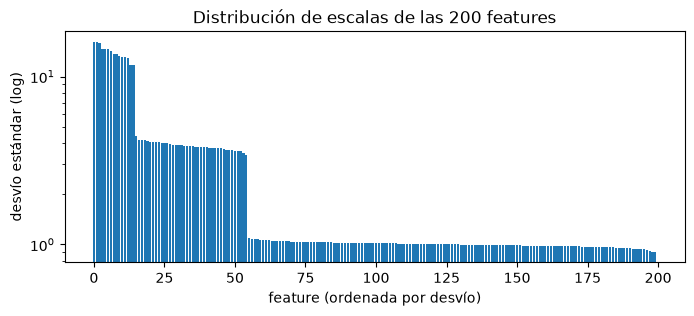

In [22]:
def resumen_escalas(X, top=10):
    desvios = X.std().sort_values(ascending=False)
    print("Features con mayor desvío:\n", desvios.head(top))
    print("\nFeatures con menor desvío:\n", desvios.tail(top))
    plt.figure(figsize=(8,3))
    plt.bar(range(len(desvios)), desvios.values)
    plt.yscale("log")
    plt.xlabel("feature (ordenada por desvío)"); plt.ylabel("desvío estándar (log)")
    plt.title("Distribución de escalas de las 200 features")
    plt.show()
    return desvios

desvios = resumen_escalas(X_dev)

Con la siguiente función podemos calcular el poder predictivo de cada feature separada, usando su valor del gen como si fuera el score de un clasificador y calculando el AUC.

In [23]:
# AUCROC de cada feature sola contra el target
def auc_univariado(X, y, top=15):
    aucs = {}
    for col in X.columns:
        auc = roc_auc_score(y, X[col])
        aucs[col] = max(auc, 1 - auc)   # una feature que ordena "al revés" también es informativa
    aucs = pd.Series(aucs).sort_values(ascending=False)
    print(f"Features con mayor AUC univariado:\n{aucs.head(top)}")
    print(f"\nCantidad de features con AUC > 0.6: {(aucs > 0.6).sum()}")
    return aucs

aucs = auc_univariado(X_dev, y_dev)

Features con mayor AUC univariado:
qWdD    0.679044
lCvP    0.653552
gmHI    0.634918
Sgqo    0.623033
OfdN    0.606448
qSdK    0.606202
PNwP    0.603907
anEO    0.597923
tkiz    0.590574
XrKM    0.588852
mhub    0.588333
Nfyr    0.584699
NkHR    0.584454
yhQS    0.582514
ISuj    0.580055
dtype: float64

Cantidad de features con AUC > 0.6: 7


Vemos a continuación que 3 de las 6 features con AUC > 0.6 también están entre las features con mayor varianza:

In [24]:
# Las features informativas son las de mayor varianza? (explica por qué escalar empeoró KNN/SVM)
print(pd.DataFrame({"auc": aucs, "std": desvios}).sort_values("auc", ascending=False).head(10))

           auc        std
qWdD  0.679044  13.658632
lCvP  0.653552   4.090320
gmHI  0.634918   3.758535
Sgqo  0.623033  13.686042
OfdN  0.606448   3.805605
qSdK  0.606202   3.633255
PNwP  0.603907   1.030150
anEO  0.597923  16.008319
tkiz  0.590574   3.854731
XrKM  0.588852   3.918994


Si bien parece haber una correlación entre poder predictivo y varianza, ¿los algoritmos realmente la están identificando? Esto lo podemos ver con la Permutation Importance con el modelo que tuvo la mejor performance de AUCROC = 0.8587:

`SVM: {'svm__kernel': 'poly', 'svm__gamma': 1, 'svm__degree': 2, 'svm__C': 1000, 'scaler': None}`



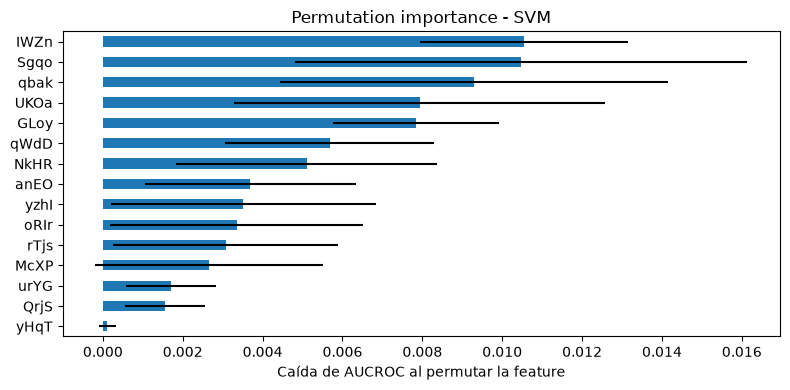

In [25]:
def importancia_permutacion(modelo, X, y, nombre, top=15):
    resultado = permutation_importance(modelo, X, y, scoring="roc_auc",
                                       n_repeats=10, random_state=random_state, n_jobs=-1)
    imp = pd.Series(resultado.importances_mean, index=X.columns).sort_values(ascending=False)
    plt.figure(figsize=(8,4))
    imp.head(top).plot(kind="barh", xerr=resultado.importances_std[imp.head(top).index.map(X.columns.get_loc)])
    plt.gca().invert_yaxis()
    plt.xlabel("Caída de AUCROC al permutar la feature")
    plt.title(f"Permutation importance - {nombre}")
    plt.tight_layout(); plt.show()
    return imp

imp_svm = importancia_permutacion(buscador_svm.best_estimator_, X_dev, y_dev, "SVM")

Calculemos la correlación entre los features con más desvío y aquellas con mayor Permutation Importance:

In [26]:
print(desvios.corr(imp_svm))

0.7988095560995575


Vemos así que hay una fuerte correlación lineal entre qué tanta varianza tiene una feature y su poder predictivo, según el modelo con mayor performance.

A partir de esto nos podemos preguntar, ¿qué ocurre si descartamos las features con menor varianza, y probamos el mismo algoritmo con los mismos parámetros posibles?


In [27]:
svm_pipe_filtrado = Pipeline([
    ("filtro", VarianceThreshold(threshold=2.0)),
    ("scaler", StandardScaler()),
    ("svm", SVC(random_state=random_state))
])

buscador_svm_filtrado = RandomizedSearchCV(estimator=svm_pipe_filtrado, param_distributions=parametros_svm,
                                           n_iter=50, scoring="roc_auc", cv=skf, random_state=random_state)

buscador_svm_filtrado.fit(X_dev, y_dev)

print("Features que pasan el filtro:", buscador_svm_filtrado.best_estimator_["filtro"].get_support().sum(), "de", X_dev.shape[1])
print("Mejores hiperparametros:", buscador_svm_filtrado.best_params_)
print(f"Mejor score AUCROC: {buscador_svm_filtrado.best_score_:.4f}")

Features que pasan el filtro: 55 de 200
Mejores hiperparametros: {'svm__kernel': 'poly', 'svm__gamma': 0.0001, 'svm__degree': 2, 'svm__C': 10, 'scaler': StandardScaler()}
Mejor score AUCROC: 0.9441


In [28]:
resultados_svm_filtrado = pd.DataFrame(buscador_svm_filtrado.cv_results_).sort_values("rank_test_score")
resultados_svm_filtrado[["params", "mean_test_score", "std_test_score"]].head(5)

,params,mean_test_score,std_test_score
4,"{'svm__kernel': 'poly', 'svm__gamma': 0.0001, 'svm__degree': 2, 'svm__C': 10, 'scaler': StandardScaler()}",0.944126,0.024355
15,"{'svm__kernel': 'poly', 'svm__gamma': 0.0001, 'svm__degree': 2, 'svm__C': 1000, 'scaler': StandardScaler()}",0.940027,0.029950
46,"{'svm__kernel': 'poly', 'svm__gamma': 0.001, 'svm__degree': 2, 'svm__C': 10, 'scaler': StandardScaler()}",0.940027,0.029950
3,"{'svm__kernel': 'poly', 'svm__gamma': 0.1, 'svm__degree': 2, 'svm__C': 0.1, 'scaler': StandardScaler()}",0.939481,0.019724
28,"{'svm__kernel': 'poly', 'svm__gamma': 0.001, 'svm__degree': 2, 'svm__C': 1000, 'scaler': StandardScaler()}",0.939481,0.019724


Podemos observar así que al eliminar las features más ruidosas, y quedándonos sólo con las de mayor varianza, pudimos mejorar la performance del modelo.

Ahora bien, ¿por qué este modelo en particular funciona mejor que el resto? Esto puede deberse a que el SVM con grado = 2 es el único de los modelos que puede ver las interacciones del tipo $x_i \cdot x_j$:
- LDA, SVM lineal por construcción sólo ven términos lineales.
- Naive Bayes puede ver términos cuadráticos pero no interacciones entre features.
- Los árboles de decisión sólo hacen cortes en cada feature, por lo que para poder hacer un corte sobre $x_i \cdot x_j$ debería hacer muchísimos cortes.
- KNN como no es paramétrico puede encontrar estas relaciones, y es por esto seguramente que queda en segundo lugar con AUCROC = 0.8474, pero sin filtrar las features, las features más ruidosas sin poder predictivo puede que estén alterando su performance.

Por último, para asegurarnos de esta intuición, podemos comparar el SVM usando diferentes tipos de polinomios: vemos en la siguiente cell que el aumento de performance se produce justamente cuando se agregan las interacciones $x_i \cdot x_j$

In [29]:
def k_cuadrados(A, B):      return (A ** 2) @ (B ** 2).T
def k_interacciones(A, B):  return (A @ B.T) ** 2 - (A ** 2) @ (B ** 2).T
def k_grado2(A, B):         return (A @ B.T) ** 2

monomios = [("solo lineales  x_i",         "linear"),
            ("solo cuadrados x_i^2",       k_cuadrados),
            ("solo interacciones x_i*x_j", k_interacciones),
            ("grado 2 completo (= poly2)", k_grado2)]

for nombre, kernel in monomios:
    scores = []
    for C in [0.001, 0.01, 0.1, 1, 10, 100]:
        pipe = Pipeline([("filtro", VarianceThreshold(threshold=2.0)),
                         ("scaler", StandardScaler()),
                         ("svm", SVC(kernel=kernel, C=C, random_state=random_state))])
        scores.append((cross_val_score(pipe, X_dev, y_dev, cv=skf, scoring="roc_auc").mean(), C))
    auc, C = max(scores)
    print(f"{nombre:28s} AUCROC = {auc}  (mejor C={C})")

solo lineales  x_i           AUCROC = 0.7189890710382513  (mejor C=0.01)
solo cuadrados x_i^2         AUCROC = 0.6025956284153005  (mejor C=0.001)
solo interacciones x_i*x_j   AUCROC = 0.9420765027322405  (mejor C=0.001)
grado 2 completo (= poly2)   AUCROC = 0.9394808743169399  (mejor C=0.001)
